In [45]:
# This file is only for EDA porposes 

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

input_path = 'data/transit_ridership.csv'
output_path = 'output'

In [46]:
df = pd.read_csv(input_path)
df = df.copy()

print(f"The data shape: {df.shape}\n\n")
df.head()

The data shape: (1993, 10)




,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday
0,2024-10-21,R205,Inbound,388.0,57.0,Minibus,77.9,Clear,-14.3,false
1,2024-08-29,R105,Outbound,457.0,169.0,Articulated Bus,76.6,Snow,-1.1,false
2,2024-08-31,R207,Inbound,NaN,518.0,Articulated Bus,58.5,Overcast,22.8,False
3,2024-12-24,R208,Outbound,354.0,302.0,Articulated Bus,47.4,Snow,29.6,0
4,2024-03-05,R207,Inbound,423.0,643.0,Minibus,17.4,Overcast,-11.7,No


In [47]:
duplicates_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates_count}")

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicates removed.")

Number of duplicate rows found: 30
Duplicates removed.


In [48]:
df['vehicle_type'].unique()

<StringArray>
[        'Minibus', 'Articulated Bus',    'Standard Bus',        'mini bus',
         'MINIBUS',         'std bus',    'standard bus',         'Std Bus',
     'articulated']
Length: 9, dtype: str

In [49]:
def clean_vehicle(val):
    val = str(val).lower().strip()
    if 'mini' in val:
        return 'Minibus'
    if 'articulated' in val:
        return 'Articulated Bus'
    if 'std' in val or 'standard' in val:
        return 'Standard Bus'
    return val.title()

df['vehicle_type'] = df['vehicle_type'].apply(clean_vehicle)
print("Standardized Vehicle Types:", df['vehicle_type'].unique())

Standardized Vehicle Types: <StringArray>
['Minibus', 'Articulated Bus', 'Standard Bus']
Length: 3, dtype: str


In [50]:
print(df['direction'].unique())
df['is_holiday'].unique()

<StringArray>
[ 'Inbound', 'Outbound', 'OUTBOUND',      'Out',  'INBOUND',       'In',
  'inbound',   'Outbnd', 'outbound',    'Inbnd']
Length: 10, dtype: str


<StringArray>
['false', 'False', '0', 'No', 'Yes', '1', 'True', 'true']
Length: 8, dtype: str

In [51]:
# Cleaning Direction
def clean_direction(val):
    val = str(val).lower()
    if 'in' in val: return 'Inbound'
    if 'out' in val: return 'Outbound'
    return val

df['direction'] = df['direction'].apply(clean_direction)

# Cleaning Holiday
holiday_map = {
    'false': False, 'False': False, '0': False, 'No': False,
    'true': True, 'True': True, '1': True, 'Yes': True
}
df['is_holiday'] = df['is_holiday'].map(holiday_map)

In [52]:
print(df['direction'].unique())
df['is_holiday'].unique()

<StringArray>
['Inbound', 'Outbound']
Length: 2, dtype: str


array([False,  True])

In [53]:
# Fix Trip Duration Outliers (using 120 mins as a reasonable cap)
median_dur = df['trip_duration_min'].median()
df.loc[(df['trip_duration_min'] < 0) | (df['trip_duration_min'] > 120), 'trip_duration_min'] = median_dur

# Impute other missing values with median
numeric_cols = ['boarding_count', 'alighting_count', 'temperature_c', 'trip_duration_min']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Create Total Ridership feature
df['total_ridership'] = df['boarding_count'] + df['alighting_count']

In [54]:
# Convert to datetime; malformatted dates become NaT
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Count how many rows will be dropped
invalid_dates = df['date'].isna().sum()
print(f"Dropping {invalid_dates} rows with invalid date formats...")

# Drop the NaT rows
df = df.dropna(subset=['date']).reset_index(drop=True)

print(f"Final cleaned data shape: {df.shape}")

Dropping 206 rows with invalid date formats...
Final cleaned data shape: (1757, 11)


In [55]:
# Extract Month for EDA
df['month'] = df['date'].dt.month_name()

# Calculate Total Ridership
df['total_ridership'] = df['boarding_count'] + df['alighting_count']

df.head()

,date,route_id,direction,boarding_count,alighting_count,vehicle_type,trip_duration_min,weather,temperature_c,is_holiday,total_ridership,month
0,2024-10-21,R205,Inbound,388.0,57.0,Minibus,77.9,Clear,-14.3,False,445.0,October
1,2024-08-29,R105,Outbound,457.0,169.0,Articulated Bus,76.6,Snow,-1.1,False,626.0,August
2,2024-08-31,R207,Inbound,412.0,518.0,Articulated Bus,58.5,Overcast,22.8,False,930.0,August
3,2024-12-24,R208,Outbound,354.0,302.0,Articulated Bus,47.4,Snow,29.6,False,656.0,December
4,2024-03-05,R207,Inbound,423.0,643.0,Minibus,17.4,Overcast,-11.7,False,1066.0,March


In [56]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

sns.set_theme(style="whitegrid")

if not os.path.exists(output_path):
    os.makedirs(output_path)

C:\Users\Pc\AppData\Local\Temp\ipykernel_19844\3068984943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_boarding_weather, x='weather', y='boarding_count', palette='Blues_d')


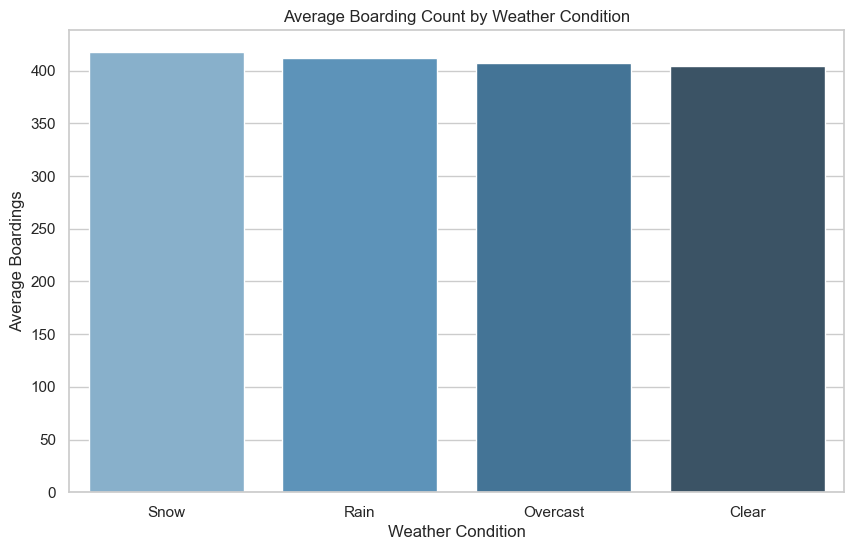

In [57]:
# 1. Avg boarding by weather condition
plt.figure(figsize=(10, 6))
avg_boarding_weather = df.groupby('weather')['boarding_count'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_boarding_weather, x='weather', y='boarding_count', palette='Blues_d')
plt.title('Average Boarding Count by Weather Condition')
plt.ylabel('Average Boardings')
plt.xlabel('Weather Condition')
plt.savefig(f"{output_path}/avg_boarding_weather.png")

C:\Users\Pc\AppData\Local\Temp\ipykernel_19844\1690578551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_duration_vehicle, x='vehicle_type', y='trip_duration_min', palette='Oranges_d')


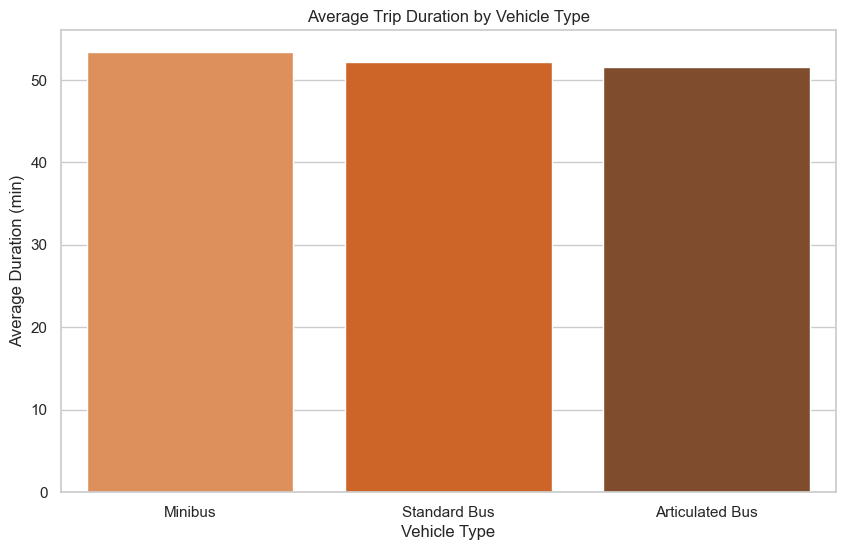

In [58]:
# 2. Avg trip duration by vehicle type
plt.figure(figsize=(10, 6))
avg_duration_vehicle = df.groupby('vehicle_type')['trip_duration_min'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=avg_duration_vehicle, x='vehicle_type', y='trip_duration_min', palette='Oranges_d')
plt.title('Average Trip Duration by Vehicle Type')
plt.ylabel('Average Duration (min)')
plt.xlabel('Vehicle Type')
plt.savefig(f'{output_path}/avg_duration_vehicle.png')

C:\Users\Pc\AppData\Local\Temp\ipykernel_19844\333450983.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=total_boarding_route, x='route_id', y='boarding_count', palette='Greens_d')


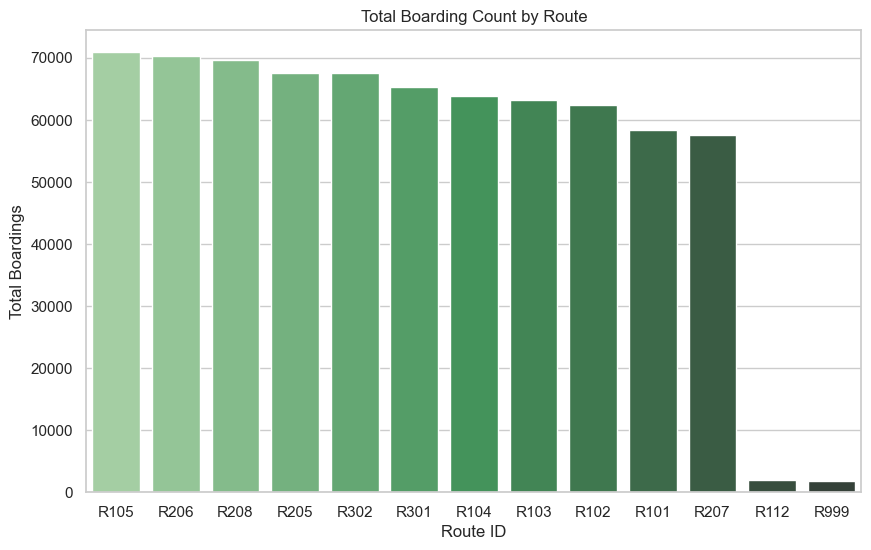

In [59]:
# 3. Total boarding by route
plt.figure(figsize=(10, 6))
total_boarding_route = df.groupby('route_id')['boarding_count'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=total_boarding_route, x='route_id', y='boarding_count', palette='Greens_d')
plt.title('Total Boarding Count by Route')
plt.ylabel('Total Boardings')
plt.xlabel('Route ID')
plt.savefig(f'{output_path}/total_boarding_route.png')

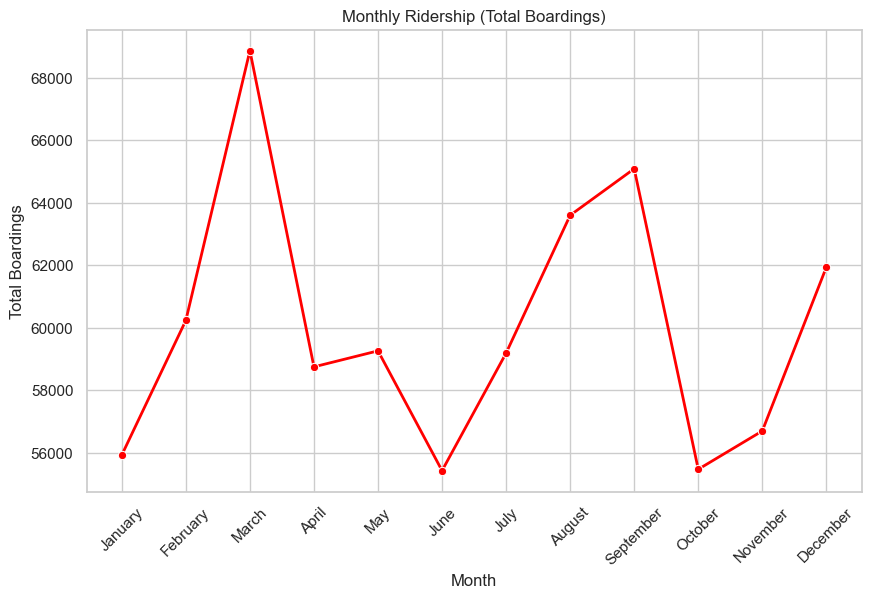

In [60]:
# 4. Monthly ridership (total boardings)
plt.figure(figsize=(10, 6))
monthly_ridership = df.groupby('month', observed=True)['boarding_count'].sum().reset_index()
sns.lineplot(data=monthly_ridership, x='month', y='boarding_count', marker='o', color='red', linewidth=2)
plt.title('Monthly Ridership (Total Boardings)')
plt.ylabel('Total Boardings')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.savefig(f'{output_path}/monthly_ridership.png')

In [62]:
total_trips = len(df)
date_range = f"{df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}"

route_totals = df.groupby('route_id')['boarding_count'].sum().sort_values(ascending=False)
busiest_route = route_totals.idxmax()

# Average Daily Ridership
# Sum boardings per day first, then take the average of those daily totals
avg_daily_ridership = df.groupby('date')['boarding_count'].sum().mean()

# Ridership by Vehicle and Weather
ridership_by_vehicle = df.groupby('vehicle_type')['boarding_count'].sum().to_dict()
ridership_by_weather = df.groupby('weather')['boarding_count'].sum().to_dict()

# Format Top 5 Routes
top_5_routes = [
    {"route": route, "total_boardings": float(total)} 
    for route, total in route_totals.head(5).items()
]

# Construct final Dictionary
summary_data = {
    "total_trips": int(total_trips),
    "date_range": date_range,
    "busiest_route": busiest_route,
    "avg_daily_ridership": round(float(avg_daily_ridership), 1),
    "ridership_by_vehicle_type": {k: float(v) for k, v in ridership_by_vehicle.items()},
    "ridership_by_weather": {k: float(v) for k, v in ridership_by_weather.items()},
    "top_5_routes_by_boarding": top_5_routes
}

# Save to JSON file
with open(f"{output_path}/summary.json", 'w') as f:
    json.dump(summary_data, f, indent=2)

print(f"Summary JSON saved to: {output_path}/summary.json")

Summary JSON saved to: output/summary.json
